In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torch.utils.data import random_split, Subset
from torchvision import datasets
from torchvision import transforms
import numpy as np
import pickle
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device


'cuda'

In [3]:
import kagglehub
path = kagglehub.dataset_download('jonathanoheix/face-expression-recognition-dataset')
print('📂 Dataset được lưu tại:', path)


📂 Dataset được lưu tại: /kaggle/input/face-expression-recognition-dataset


In [4]:
import torchvision
import torch
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from pathlib import Path
import numpy as np
image_dir = Path('/kaggle/input/face-expression-recognition-dataset')


In [5]:
import os

def walk_through_dir(dir_path):
    """Walk through dir_path returning its contents"""
    for (dirpath, dirnames, filenames) in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'")


In [6]:
walk_through_dir(image_dir)

There are 1 directories and 0 images in '/kaggle/input/face-expression-recognition-dataset'
There are 3 directories and 0 images in '/kaggle/input/face-expression-recognition-dataset/images'
There are 7 directories and 0 images in '/kaggle/input/face-expression-recognition-dataset/images/validation'
There are 0 directories and 797 images in '/kaggle/input/face-expression-recognition-dataset/images/validation/surprise'
There are 0 directories and 1018 images in '/kaggle/input/face-expression-recognition-dataset/images/validation/fear'
There are 0 directories and 960 images in '/kaggle/input/face-expression-recognition-dataset/images/validation/angry'
There are 0 directories and 1216 images in '/kaggle/input/face-expression-recognition-dataset/images/validation/neutral'
There are 0 directories and 1139 images in '/kaggle/input/face-expression-recognition-dataset/images/validation/sad'
There are 0 directories and 111 images in '/kaggle/input/face-expression-recognition-dataset/images/vali

In [7]:
import random
from PIL import Image
import requests
import zipfile
from pathlib import Path
import os
import matplotlib.pyplot as plt
image_path_list = list(image_dir.glob('**/*.jpg'))


/kaggle/input/face-expression-recognition-dataset/images/train/neutral/28228.jpg
neutral
Random image path: /kaggle/input/face-expression-recognition-dataset/images/train/neutral/28228.jpg
Image class: neutral
Image height: 48
Image width: 48


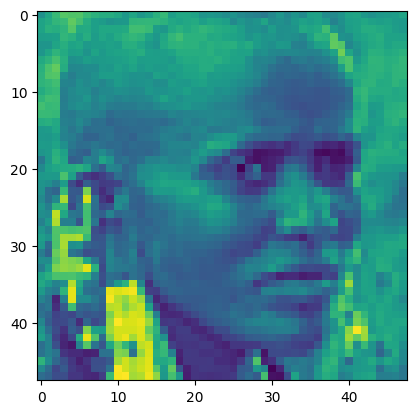

In [8]:
random_image_path = random.choice(image_path_list)
print(random_image_path)
image_class = random_image_path.parent.stem
print(image_class)
image = Image.open(random_image_path)
print(f'Random image path: {random_image_path}')
print(f'Image class: {image_class}')
print(f'Image height: {image.height}')
print(f'Image width: {image.width}')
plt.imshow(image)


In [9]:
print(len(image_path_list))

71774


In [10]:
from torchvision import transforms
train_transform = transforms.Compose([transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(p=0.5), transforms.RandomVerticalFlip(p=0.1), transforms.ToTensor()])
test_transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])


In [11]:
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import random_split, Subset, ConcatDataset
train_dir = image_dir / 'images' / 'train'
val_dir = image_dir / 'images' / 'validation'
train_full = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_full = datasets.ImageFolder(root=val_dir, transform=test_transform)
full_data = ConcatDataset([train_full, val_full])
subset_indices = random.sample(range(len(full_data)), 20000)
subset_dataset = Subset(full_data, subset_indices)
train_size = int(0.8 * len(subset_dataset))
test_size = len(subset_dataset) - train_size
(train_indices, test_indices) = random_split(range(len(subset_dataset)), [train_size, test_size])
train_data = Subset(subset_dataset, train_indices)
test_data = Subset(subset_dataset, test_indices)


In [12]:
print(len(full_data), len(train_data), len(test_data))
train_full.classes


35887 16000 4000


['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

In [13]:
class_to_idx = full_data.datasets[0].class_to_idx
print('class_to_idx:', class_to_idx)


class_to_idx: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [14]:
from torch.utils.data import DataLoader
BATCH_SIZE = 8
train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, num_workers=1, shuffle=True)
test_dataloader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, num_workers=1, shuffle=False)
(len(train_dataloader), len(test_dataloader), train_dataloader, test_dataloader)


(2000,
 500,
 <torch.utils.data.dataloader.DataLoader at 0x7a1f7ba5de50>)

In [15]:
(img, label) = next(iter(train_dataloader))
print(f'Image shape: {img.shape} -> [batch_size, color_channels, height, width]')
print(f'Label shape: {label.shape}')


Image shape: torch.Size([8, 3, 224, 224]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([8])


**MobileNetV1**

In [16]:
import torch.nn as nn
from torchsummary import summary

class MobileNetV1(nn.Module):

    def __init__(self, ch_in, n_classes):
        super(MobileNetV1, self).__init__()

        def conv_bn(inp, oup, stride):
            return nn.Sequential(nn.Conv2d(inp, oup, 3, stride, 1, bias=False), nn.BatchNorm2d(oup), nn.ReLU(inplace=True))

        def conv_dw(inp, oup, stride):
            return nn.Sequential(nn.Conv2d(inp, inp, 3, stride, 1, groups=inp, bias=False), nn.BatchNorm2d(inp), nn.ReLU(inplace=True), nn.Conv2d(inp, oup, 1, 1, 0, bias=False), nn.BatchNorm2d(oup), nn.ReLU(inplace=True))
        self.model = nn.Sequential(conv_bn(ch_in, 32, 2), conv_dw(32, 64, 1), conv_dw(64, 128, 2), conv_dw(128, 128, 1), conv_dw(128, 256, 2), conv_dw(256, 256, 1), conv_dw(256, 512, 2), conv_dw(512, 512, 1), conv_dw(512, 512, 1), conv_dw(512, 512, 1), conv_dw(512, 512, 1), conv_dw(512, 512, 1), conv_dw(512, 1024, 2), conv_dw(1024, 1024, 1), nn.AdaptiveAvgPool2d(1))
        self.fc = nn.Linear(1024, n_classes)

    def forward(self, x):
        x = self.model(x)
        x = x.view(-1, 1024)
        x = self.fc(x)
        return x
model = MobileNetV1(3, len(train_full.classes)).to(device)
x = torch.rand(8, 3, 224, 224).to(device)
y = model(x)
y.shape


torch.Size([8, 7])

In [17]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [18]:
try:
  import torchinfo
except:

  !pip install torchinfo

  import torchinfo
from torchinfo import summary
summary(model,input_size=[32,3,64,64])


Layer (type:depth-idx)                   Output Shape              Param #
MobileNetV1                              [32, 7]                   --
├─Sequential: 1-1                        [32, 1024, 1, 1]          --
│    └─Sequential: 2-1                   [32, 32, 32, 32]          --
│    │    └─Conv2d: 3-1                  [32, 32, 32, 32]          864
│    │    └─BatchNorm2d: 3-2             [32, 32, 32, 32]          64
│    │    └─ReLU: 3-3                    [32, 32, 32, 32]          --
│    └─Sequential: 2-2                   [32, 64, 32, 32]          --
│    │    └─Conv2d: 3-4                  [32, 32, 32, 32]          288
│    │    └─BatchNorm2d: 3-5             [32, 32, 32, 32]          64
│    │    └─ReLU: 3-6                    [32, 32, 32, 32]          --
│    │    └─Conv2d: 3-7                  [32, 64, 32, 32]          2,048
│    │    └─BatchNorm2d: 3-8             [32, 64, 32, 32]          128
│    │    └─ReLU: 3-9                    [32, 64, 32, 32]          --
│    └─Se

In [19]:
def accuracy(output, label):
    label = label.data.cpu()
    true_label = torch.argmax(output.data.cpu(), dim=1)
    is_correct = true_label == label
    return is_correct.sum().item()


In [20]:
def train_step(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, optimizer: torch.optim.Optimizer):
    model.train()
    (train_loss, train_acc) = (0, 0)
    for (batch, (X, y)) in enumerate(dataloader):
        (X, y) = (X.to(device), y.to(device))
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return (train_loss, train_acc)


In [21]:
def test_step(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module):
    model.eval()
    (test_loss, test_acc) = (0, 0)
    with torch.inference_mode():
        for (batch, (X, y)) in enumerate(dataloader):
            (X, y) = (X.to(device), y.to(device))
            test_pred_logits = model(X)
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += (test_pred_labels == y).sum().item() / len(test_pred_labels)
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return (test_loss, test_acc)


In [22]:
from tqdm.auto import tqdm

def train(model: torch.nn.Module, train_dataloader: torch.utils.data.DataLoader, test_dataloader: torch.utils.data.DataLoader, optimizer: torch.optim.Optimizer, loss_fn: torch.nn.Module=nn.CrossEntropyLoss(), epochs: int=5):
    results = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    for epoch in tqdm(range(epochs)):
        (train_loss, train_acc) = train_step(model=model, dataloader=train_dataloader, loss_fn=loss_fn, optimizer=optimizer)
        (test_loss, test_acc) = test_step(model=model, dataloader=test_dataloader, loss_fn=loss_fn)
        print(f'Epoch: {epoch + 1} | train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | test_loss: {test_loss:.4f} | test_acc: {test_acc:.4f}')
        results['train_loss'].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results['train_acc'].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results['test_loss'].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results['test_acc'].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)
    return results


In [23]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
NUM_EPOCHS = 100
model = MobileNetV1(3, len(train_full.classes)).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)
from timeit import default_timer as timer
start_time = timer()
model_results = train(model=model, train_dataloader=train_dataloader, test_dataloader=test_dataloader, optimizer=optimizer, loss_fn=loss_fn, epochs=NUM_EPOCHS)
end_time = timer()
print(f'Total training time: {end_time - start_time:.3f} seconds')


  0%|          | 0/100 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.7202 | train_acc: 0.3117 | test_loss: 1.6076 | test_acc: 0.3580
Epoch: 2 | train_loss: 1.5033 | train_acc: 0.4170 | test_loss: 2.0627 | test_acc: 0.2780
Epoch: 3 | train_loss: 1.3875 | train_acc: 0.4662 | test_loss: 1.3485 | test_acc: 0.4813
Epoch: 4 | train_loss: 1.2916 | train_acc: 0.5047 | test_loss: 1.3085 | test_acc: 0.5002
Epoch: 5 | train_loss: 1.2274 | train_acc: 0.5318 | test_loss: 1.3288 | test_acc: 0.5138
Epoch: 6 | train_loss: 1.1543 | train_acc: 0.5580 | test_loss: 1.2878 | test_acc: 0.5377
Epoch: 7 | train_loss: 1.0984 | train_acc: 0.5816 | test_loss: 1.1962 | test_acc: 0.5473
Epoch: 8 | train_loss: 1.0381 | train_acc: 0.6082 | test_loss: 1.2189 | test_acc: 0.5555
Epoch: 9 | train_loss: 0.9909 | train_acc: 0.6250 | test_loss: 1.1923 | test_acc: 0.5730
Epoch: 10 | train_loss: 0.9396 | train_acc: 0.6458 | test_loss: 1.1695 | test_acc: 0.5717
Epoch: 11 | train_loss: 0.8802 | train_acc: 0.6746 | test_loss: 1.1480 | test_acc: 0.5805
Epoch: 12 | train_l

In [24]:
from typing import Tuple, Dict, List

def plot_loss_curves(results: Dict[str, List[float]]):
    loss = results['train_loss']
    test_loss = results['test_loss']
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']
    epochs = range(len(results['train_loss']))
    plt.figure(figsize=(15, 7))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend()


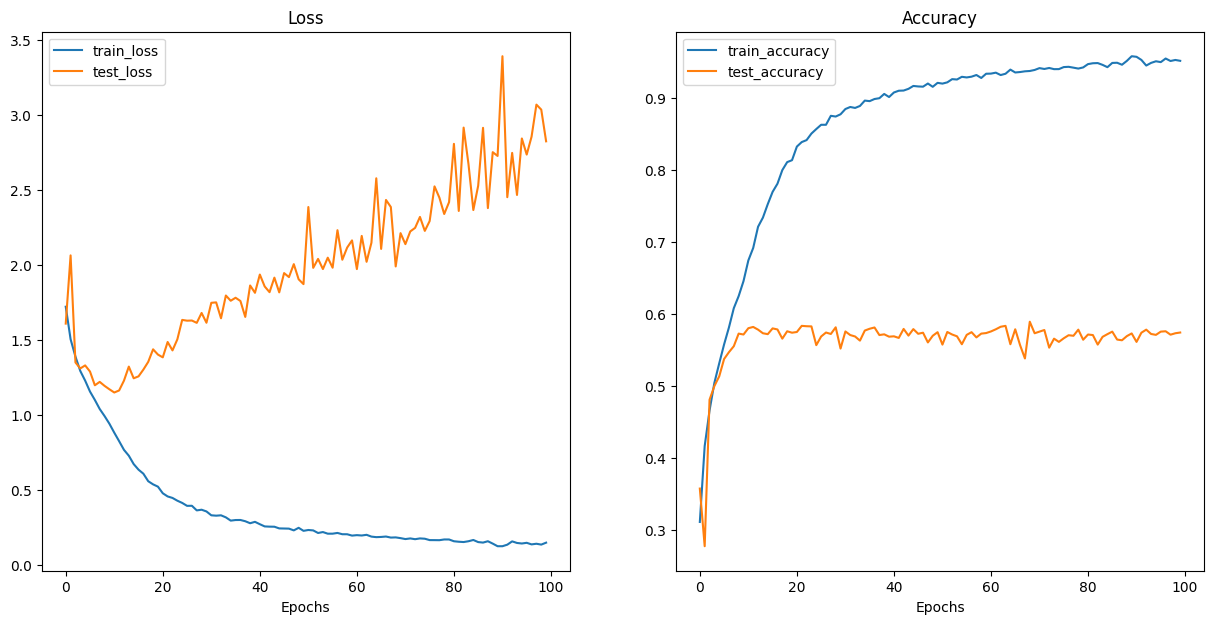

In [25]:
plot_loss_curves(model_results)

**MobileNetV2**

In [26]:
def make_divisible(v, divisor, min_value=None):
    """
    Đảm bảo rằng tất cả các lớp kênh đều có số kênh là bội số của 8.
    """
    if min_value is None:
        min_value = divisor
    new_v = max(min_value, int(v + divisor / 2) // divisor * divisor)
    if new_v < 0.9 * v:
        new_v += divisor
    return new_v


In [27]:
def dwise_conv(ch_in, stride=1):
    """Tạo một lớp tích chập theo chiều sâu (Depthwise Convolution) 3x3."""
    return nn.Sequential(nn.Conv2d(ch_in, ch_in, kernel_size=3, padding=1, stride=stride, groups=ch_in, bias=False), nn.BatchNorm2d(ch_in), nn.ReLU6(inplace=True))

def conv1x1(ch_in, ch_out):
    """Tạo một lớp tích chập điểm (Pointwise Convolution) 1x1."""
    return nn.Sequential(nn.Conv2d(ch_in, ch_out, kernel_size=1, padding=0, stride=1, bias=False), nn.BatchNorm2d(ch_out), nn.ReLU6(inplace=True))

def conv3x3(ch_in, ch_out, stride):
    """Tạo một lớp tích chập tiêu chuẩn (Standard Convolution) 3x3."""
    return nn.Sequential(nn.Conv2d(ch_in, ch_out, kernel_size=3, padding=1, stride=stride, bias=False), nn.BatchNorm2d(ch_out), nn.ReLU6(inplace=True))

class InvertedBlock(nn.Module):

    def __init__(self, ch_in, ch_out, expand_ratio, stride):
        super(InvertedBlock, self).__init__()
        self.stride = stride
        assert stride in [1, 2]
        hidden_dim = int(ch_in * expand_ratio)
        self.use_res_connect = self.stride == 1 and ch_in == ch_out
        layers = []
        if expand_ratio != 1:
            layers.append(conv1x1(ch_in, hidden_dim))
        layers.extend([nn.Sequential(nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3, stride=stride, padding=1, groups=hidden_dim, bias=False), nn.BatchNorm2d(hidden_dim), nn.ReLU6(inplace=True), nn.Conv2d(hidden_dim, ch_out, kernel_size=1, stride=1, padding=0, bias=False), nn.BatchNorm2d(ch_out))])
        self.layers = nn.Sequential(*layers)

    def forward(self, xV2):
        if self.use_res_connect:
            return xV2 + self.layers(xV2)
        else:
            return self.layers(xV2)


In [28]:
class MobileNetV2(nn.Module):

    def __init__(self, ch_in=3, n_classes=1000):
        super(MobileNetV2, self).__init__()
        self.configs = [[1, 16, 1, 1], [6, 24, 2, 2], [6, 32, 3, 2], [6, 64, 4, 2], [6, 96, 3, 1], [6, 160, 3, 2], [6, 320, 1, 1]]
        self.stem_conv = conv3x3(ch_in=3, ch_out=32, stride=2)
        layers = []
        input_channel = 32
        for (t, c, n, s) in self.configs:
            for i in range(n):
                stride = s if i == 0 else 1
                layers.append(InvertedBlock(ch_in=input_channel, ch_out=c, expand_ratio=t, stride=stride))
                input_channel = c
        self.layers = nn.Sequential(*layers)
        self.last_conv = conv1x1(input_channel, 1280)
        self.classifier = nn.Sequential(nn.Dropout(0.2), nn.Linear(1280, n_classes))
        self.avg_pool = nn.AdaptiveAvgPool2d(1)

    def forward(self, xV2):
        xV2 = self.stem_conv(xV2)
        xV2 = self.layers(xV2)
        xV2 = self.last_conv(xV2)
        xV2 = self.avg_pool(xV2).view(-1, 1280)
        xV2 = self.classifier(xV2)
        return xV2
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = len(train_full.classes)
modelV2 = MobileNetV2(n_classes=num_classes).to(device)
xV2 = torch.rand(8, 3, 224, 224).to(device)
yV2 = modelV2(xV2)
print(yV2.shape)


torch.Size([8, 7])


In [29]:
loss_fnV2 = nn.CrossEntropyLoss()
optimizerV2 = torch.optim.Adam(modelV2.parameters(), lr=0.001)


In [30]:
try:
  import torchinfo
except:

  !pip install torchinfo

  import torchinfo
from torchinfo import summary
summary(modelV2,input_size=[32,3,64,64])


Layer (type:depth-idx)                        Output Shape              Param #
MobileNetV2                                   [32, 7]                   --
├─Sequential: 1-1                             [32, 32, 32, 32]          --
│    └─Conv2d: 2-1                            [32, 32, 32, 32]          864
│    └─BatchNorm2d: 2-2                       [32, 32, 32, 32]          64
│    └─ReLU6: 2-3                             [32, 32, 32, 32]          --
├─Sequential: 1-2                             [32, 320, 2, 2]           --
│    └─InvertedBlock: 2-4                     [32, 16, 32, 32]          --
│    │    └─Sequential: 3-1                   [32, 16, 32, 32]          896
│    └─InvertedBlock: 2-5                     [32, 24, 16, 16]          --
│    │    └─Sequential: 3-2                   [32, 24, 16, 16]          5,136
│    └─InvertedBlock: 2-6                     [32, 24, 16, 16]          --
│    │    └─Sequential: 3-3                   [32, 24, 16, 16]          8,832
│    └─Inver

In [31]:
def accuracyV2(outputV2, labelV2):
    labelV2 = labelV2.data.cpu()
    true_labelV2 = torch.argmax(outputV2.data.cpu(), dim=1)
    is_correctV2 = true_labelV2 == labelV2
    return is_correctV2.sum().item()


In [32]:
def train_stepV2(modelV2: torch.nn.Module, dataloader: torch.utils.data.DataLoader, loss_fnV2: torch.nn.Module, optimizerV2: torch.optim.Optimizer, device: torch.device):
    modelV2.train()
    (train_lossV2, train_accV2) = (0, 0)
    for (batch, (XV2, yV2)) in enumerate(dataloader):
        (XV2, yV2) = (XV2.to(device), yV2.to(device))
        y_predV2 = modelV2(XV2)
        lossV2 = loss_fnV2(y_predV2, yV2)
        train_lossV2 += lossV2.item()
        optimizerV2.zero_grad()
        lossV2.backward()
        optimizerV2.step()
        y_pred_classV2 = torch.argmax(torch.softmax(y_predV2, dim=1), dim=1)
        train_accV2 += (y_pred_classV2 == yV2).sum().item() / len(y_predV2)
    train_lossV2 /= len(dataloader)
    train_accV2 /= len(dataloader)
    return (train_lossV2, train_accV2)


In [33]:
def test_stepV2(modelV2: torch.nn.Module, dataloader: torch.utils.data.DataLoader, loss_fnV2: torch.nn.Module, device: torch.device):
    modelV2.eval()
    (test_lossV2, test_accV2) = (0, 0)
    with torch.inference_mode():
        for (batch, (XV2, yV2)) in enumerate(dataloader):
            (XV2, yV2) = (XV2.to(device), yV2.to(device))
            test_pred_logitsV2 = modelV2(XV2)
            lossV2 = loss_fnV2(test_pred_logitsV2, yV2)
            test_lossV2 += lossV2.item()
            test_pred_labelsV2 = test_pred_logitsV2.argmax(dim=1)
            test_accV2 += (test_pred_labelsV2 == yV2).sum().item() / len(test_pred_labelsV2)
    test_lossV2 /= len(dataloader)
    test_accV2 /= len(dataloader)
    return (test_lossV2, test_accV2)


In [34]:
from tqdm.auto import tqdm

def trainV2(modelV2: torch.nn.Module, train_dataloader: torch.utils.data.DataLoader, test_dataloader: torch.utils.data.DataLoader, optimizerV2: torch.optim.Optimizer, loss_fnV2: torch.nn.Module, epochs: int):
    results = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    for epoch in tqdm(range(epochs)):
        (train_lossV2, train_accV2) = train_stepV2(modelV2, train_dataloader, loss_fnV2, optimizerV2, device)
        (test_lossV2, test_accV2) = test_stepV2(modelV2, test_dataloader, loss_fnV2, device)
        print(f'Epoch: {epoch + 1} | train_loss: {train_lossV2:.4f} | train_acc: {train_accV2:.4f} | test_loss: {test_lossV2:.4f} | test_acc: {test_accV2:.4f}')
        results['train_loss'].append(train_lossV2)
        results['train_acc'].append(train_accV2)
        results['test_loss'].append(test_lossV2)
        results['test_acc'].append(test_accV2)
    return results


In [35]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
NUM_EPOCHSV2 = 50
modelV2 = MobileNetV2(len(train_full.classes)).to(device)
loss_fnV2 = nn.CrossEntropyLoss()
optimizerV2 = torch.optim.Adam(params=modelV2.parameters(), lr=0.001)
from timeit import default_timer as timer
start_time = timer()
model_results = trainV2(modelV2=modelV2, train_dataloader=train_dataloader, test_dataloader=test_dataloader, optimizerV2=optimizerV2, loss_fnV2=loss_fnV2, epochs=NUM_EPOCHSV2)
end_time = timer()
print(f'Total training time: {end_time - start_time:.3f} seconds')


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.7893 | train_acc: 0.2738 | test_loss: 1.7325 | test_acc: 0.3220
Epoch: 2 | train_loss: 1.5792 | train_acc: 0.3779 | test_loss: 1.4593 | test_acc: 0.4340
Epoch: 3 | train_loss: 1.4628 | train_acc: 0.4303 | test_loss: 1.3836 | test_acc: 0.4570
Epoch: 4 | train_loss: 1.3954 | train_acc: 0.4556 | test_loss: 1.3661 | test_acc: 0.4667
Epoch: 5 | train_loss: 1.3361 | train_acc: 0.4828 | test_loss: 1.2702 | test_acc: 0.5085
Epoch: 6 | train_loss: 1.2798 | train_acc: 0.5104 | test_loss: 1.3154 | test_acc: 0.4928
Epoch: 7 | train_loss: 1.2370 | train_acc: 0.5259 | test_loss: 1.2573 | test_acc: 0.5248
Epoch: 8 | train_loss: 1.2043 | train_acc: 0.5379 | test_loss: 1.2230 | test_acc: 0.5350
Epoch: 9 | train_loss: 1.1737 | train_acc: 0.5521 | test_loss: 1.2155 | test_acc: 0.5467
Epoch: 10 | train_loss: 1.1408 | train_acc: 0.5677 | test_loss: 1.1912 | test_acc: 0.5523
Epoch: 11 | train_loss: 1.1167 | train_acc: 0.5749 | test_loss: 1.1991 | test_acc: 0.5475
Epoch: 12 | train_l

In [36]:
from typing import Tuple, Dict, List

def plot_loss_curves(results: Dict[str, List[float]]):
    loss = results['train_loss']
    test_loss = results['test_loss']
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']
    epochs = range(len(results['train_loss']))
    plt.figure(figsize=(15, 7))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend()


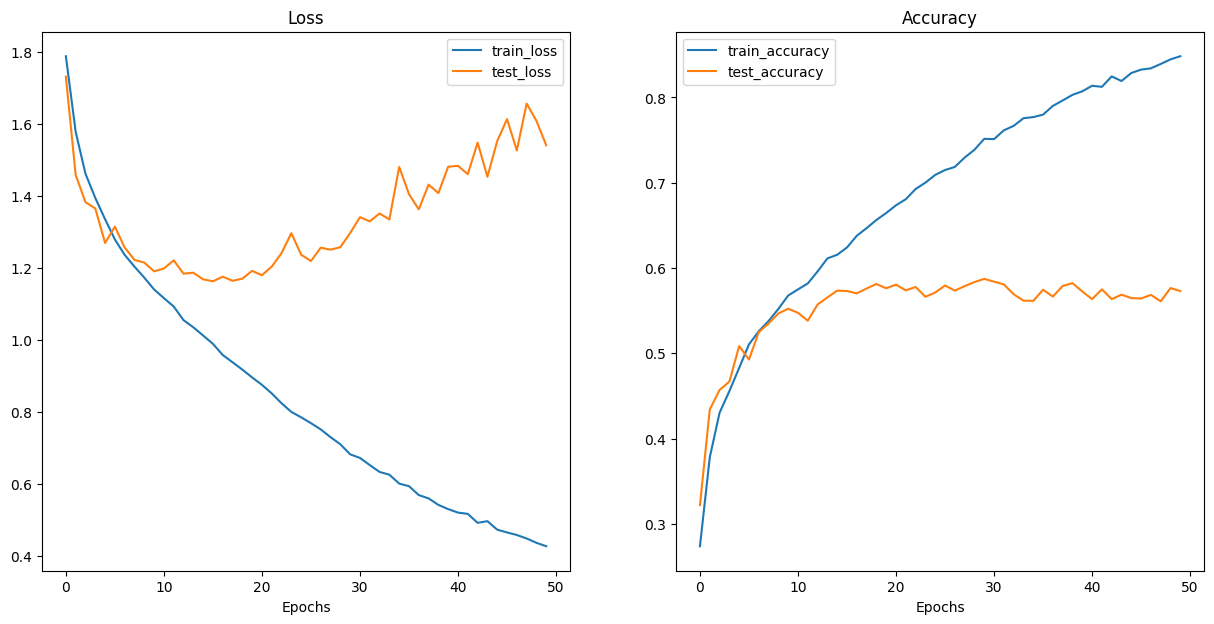

In [37]:
plot_loss_curves(model_results)

**MobileNetV3**

In [38]:
def make_divisible(v, divisor, min_value=None):
    """Đảm bảo số kênh luôn là bội số của 8."""
    if min_value is None:
        min_value = divisor
    new_v = max(min_value, int(v + divisor / 2) // divisor * divisor)
    if new_v < 0.9 * v:
        new_v += divisor
    return new_v


In [39]:
class HSwish(nn.Module):
    """Triển khai Hard-Swish."""

    def __init__(self, inplace=True):
        super(HSwish, self).__init__()
        self.inplace = inplace

    def forward(self, xV3):
        return xV3 * F.relu6(xV3 + 3, inplace=self.inplace) / 6


In [40]:
class SqueezeExcitation(nn.Module):
    """Khối Squeeze-and-Excitation với Hard-Sigmoid."""

    def __init__(self, in_channels, reduction_ratio=4):
        super(SqueezeExcitation, self).__init__()
        reduced_channels = make_divisible(in_channels // reduction_ratio, 8)
        self.se = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Conv2d(in_channels, reduced_channels, kernel_size=1), nn.ReLU(inplace=True), nn.Conv2d(reduced_channels, in_channels, kernel_size=1), nn.Hardsigmoid(inplace=True))

    def forward(self, xV3):
        return xV3 * self.se(xV3)


In [41]:
class InvertedResidualBlock(nn.Module):
    """Khối Inverted Residual linh hoạt, nhận lớp kích hoạt làm tham số."""

    def __init__(self, in_channels, out_channels, kernel_size, stride, expand_ratio, use_se, activation):
        super(InvertedResidualBlock, self).__init__()
        self.stride = stride
        self.use_res_connect = self.stride == 1 and in_channels == out_channels
        hidden_dim = int(in_channels * expand_ratio)
        layers = []
        if expand_ratio != 1:
            layers.extend([nn.Conv2d(in_channels, hidden_dim, kernel_size=1, bias=False), nn.BatchNorm2d(hidden_dim), activation(inplace=True)])
        layers.extend([nn.Conv2d(hidden_dim, hidden_dim, kernel_size=kernel_size, stride=stride, padding=kernel_size // 2, groups=hidden_dim, bias=False), nn.BatchNorm2d(hidden_dim), activation(inplace=True)])
        if use_se:
            layers.append(SqueezeExcitation(hidden_dim))
        layers.extend([nn.Conv2d(hidden_dim, out_channels, kernel_size=1, bias=False), nn.BatchNorm2d(out_channels)])
        self.conv = nn.Sequential(*layers)

    def forward(self, xV3):
        if self.use_res_connect:
            return xV3 + self.conv(xV3)
        else:
            return self.conv(xV3)


In [42]:
class MobileNetV3(nn.Module):

    def __init__(self, mode, num_classes=1000, width_mult=1.0, dropout=0.2):
        super(MobileNetV3, self).__init__()
        if mode == 'large':
            self.cfgs = [[3, 1, 16, False, nn.ReLU, 1], [3, 4, 24, False, nn.ReLU, 2], [3, 3, 24, False, nn.ReLU, 1], [5, 3, 40, True, nn.ReLU, 2], [5, 3, 40, True, nn.ReLU, 1], [5, 3, 40, True, nn.ReLU, 1], [3, 6, 80, False, HSwish, 2], [3, 2.5, 80, False, HSwish, 1], [3, 2.3, 80, False, HSwish, 1], [3, 2.3, 80, False, HSwish, 1], [3, 6, 112, True, HSwish, 1], [3, 6, 112, True, HSwish, 1], [5, 6, 160, True, HSwish, 2], [5, 6, 160, True, HSwish, 1], [5, 6, 160, True, HSwish, 1]]
            last_conv_out = 960
            classifier_hidden = 1280
        elif mode == 'small':
            self.cfgs = [[3, 1, 16, True, nn.ReLU, 2], [3, 4.5, 24, False, nn.ReLU, 2], [3, 3.67, 24, False, nn.ReLU, 1], [5, 4, 40, True, HSwish, 2], [5, 6, 40, True, HSwish, 1], [5, 6, 40, True, HSwish, 1], [5, 3, 48, True, HSwish, 1], [5, 3, 48, True, HSwish, 1], [5, 6, 96, True, HSwish, 2], [5, 6, 96, True, HSwish, 1], [5, 6, 96, True, HSwish, 1]]
            last_conv_out = 576
            classifier_hidden = 1024
        else:
            raise ValueError(f'Unsupported mode: {mode}')
        input_channel = 16
        input_channel = make_divisible(input_channel * width_mult, 8)
        self.first_conv = nn.Sequential(nn.Conv2d(3, input_channel, kernel_size=3, stride=2, padding=1, bias=False), nn.BatchNorm2d(input_channel), HSwish(inplace=True))
        self.blocks = nn.ModuleList([])
        for (k, t, c, use_se, nl, s) in self.cfgs:
            output_channel = make_divisible(c * width_mult, 8)
            expand_ratio = t
            self.blocks.append(InvertedResidualBlock(input_channel, output_channel, k, s, expand_ratio, use_se, nl))
            input_channel = output_channel
        last_conv_out = make_divisible(last_conv_out * width_mult, 8)
        self.last_conv = nn.Sequential(nn.Conv2d(input_channel, last_conv_out, kernel_size=1, bias=False), nn.BatchNorm2d(last_conv_out), HSwish(inplace=True))
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(nn.Linear(last_conv_out, classifier_hidden), HSwish(inplace=True), nn.Dropout(p=dropout), nn.Linear(classifier_hidden, num_classes))

    def forward(self, xV3):
        xV3 = self.first_conv(xV3)
        for block in self.blocks:
            xV3 = block(xV3)
        xV3 = self.last_conv(xV3)
        xV3 = self.avgpool(xV3)
        xV3 = xV3.view(xV3.size(0), -1)
        xV3 = self.classifier(xV3)
        return xV3
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
modelV3 = MobileNetV3(mode='small', num_classes=10, width_mult=0.75).to(device)
xV3 = torch.rand(8, 3, 224, 224).to(device)
yV3 = modelV3(xV3)
print(yV3.shape)


torch.Size([8, 10])


In [43]:
loss_fnV3 = nn.CrossEntropyLoss()
optimizerV3 = torch.optim.Adam(modelV3.parameters(), lr=0.001)


In [44]:
try:
  import torchinfo
except:

  !pip install torchinfo

  import torchinfo
from torchinfo import summary
summary(modelV3,input_size=[32,3,64,64])


Layer (type:depth-idx)                                  Output Shape              Param #
MobileNetV3                                             [32, 10]                  --
├─Sequential: 1-1                                       [32, 16, 32, 32]          --
│    └─Conv2d: 2-1                                      [32, 16, 32, 32]          432
│    └─BatchNorm2d: 2-2                                 [32, 16, 32, 32]          32
│    └─HSwish: 2-3                                      [32, 16, 32, 32]          --
├─ModuleList: 1-2                                       --                        --
│    └─InvertedResidualBlock: 2-4                       [32, 16, 16, 16]          --
│    │    └─Sequential: 3-1                             [32, 16, 16, 16]          744
│    └─InvertedResidualBlock: 2-5                       [32, 24, 8, 8]            --
│    │    └─Sequential: 3-2                             [32, 24, 8, 8]            3,864
│    └─InvertedResidualBlock: 2-6                      

In [45]:
def accuracy(output, labelV3):
    labelV3 = labelV3.data.cpu()
    true_labelV3 = torch.argmax(output.data.cpu(), dim=1)
    is_correctV3 = true_labelV3 == labelV3
    return is_correctV3.sum().item()


In [46]:
def train_stepV3(modelV3: torch.nn.Module, dataloader: torch.utils.data.DataLoader, loss_fnV3: torch.nn.Module, optimizerV3: torch.optim.Optimizer):
    modelV3.train()
    (train_lossV3, train_accV3) = (0, 0)
    for (batch, (XV3, yV3)) in enumerate(dataloader):
        (XV3, yV3) = (XV3.to(device), yV3.to(device))
        y_predV3 = modelV3(XV3)
        lossV3 = loss_fnV3(y_predV3, yV3)
        train_lossV3 += lossV3.item()
        optimizerV3.zero_grad()
        lossV3.backward()
        optimizerV3.step()
        y_pred_classV3 = torch.argmax(torch.softmax(y_predV3, dim=1), dim=1)
        train_accV3 += (y_pred_classV3 == yV3).sum().item() / len(y_predV3)
    train_lossV3 = train_lossV3 / len(dataloader)
    train_accV3 = train_accV3 / len(dataloader)
    return (train_lossV3, train_accV3)


In [47]:
def test_stepV3(modelV3: torch.nn.Module, dataloader: torch.utils.data.DataLoader, loss_fnV3: torch.nn.Module):
    modelV3.eval()
    (test_lossV3, test_accV3) = (0, 0)
    with torch.inference_mode():
        for (batch, (XV3, yV3)) in enumerate(dataloader):
            (XV3, yV3) = (XV3.to(device), yV3.to(device))
            test_pred_logitsV3 = modelV3(XV3)
            lossV3 = loss_fnV3(test_pred_logitsV3, yV3)
            test_lossV3 += lossV3.item()
            test_pred_labelsV3 = test_pred_logitsV3.argmax(dim=1)
            test_accV3 += (test_pred_labelsV3 == yV3).sum().item() / len(test_pred_labelsV3)
    test_lossV3 = test_lossV3 / len(dataloader)
    test_accV3 = test_accV3 / len(dataloader)
    return (test_lossV3, test_accV3)


In [48]:
from tqdm.auto import tqdm

def trainV3(modelV3: torch.nn.Module, train_dataloader: torch.utils.data.DataLoader, test_dataloader: torch.utils.data.DataLoader, optimizerV3: torch.optim.Optimizer, loss_fnV3: torch.nn.Module=nn.CrossEntropyLoss(), epochs: int=5, device=device):
    results = {'train_lossV3': [], 'train_accV3': [], 'test_lossV3': [], 'test_accV3': []}
    for epoch in tqdm(range(epochs)):
        (train_lossV3, train_accV3) = train_stepV3(modelV3=modelV3, dataloader=train_dataloader, loss_fnV3=loss_fnV3, optimizerV3=optimizerV3)
        (test_lossV3, test_accV3) = test_stepV3(modelV3=modelV3, dataloader=test_dataloader, loss_fnV3=loss_fnV3)
        print(f'Epoch: {epoch + 1} | train_loss: {train_lossV3:.4f} | train_acc: {train_accV3:.4f} | test_loss: {test_lossV3:.4f} | test_acc: {test_accV3:.4f}')
        results['train_lossV3'].append(train_lossV3.item() if isinstance(train_lossV3, torch.Tensor) else train_lossV3)
        results['train_accV3'].append(train_accV3.item() if isinstance(train_accV3, torch.Tensor) else train_accV3)
        results['test_lossV3'].append(test_lossV3.item() if isinstance(test_lossV3, torch.Tensor) else test_lossV3)
        results['test_accV3'].append(test_accV3.item() if isinstance(test_accV3, torch.Tensor) else test_accV3)
    return results


In [49]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
NUM_EPOCHS = 50
modelV3 = MobileNetV3(mode='small', num_classes=len(train_full.classes)).to(device)
loss_fnV3 = nn.CrossEntropyLoss()
optimizerV3 = torch.optim.Adam(params=modelV3.parameters(), lr=0.001)
from timeit import default_timer as timer
start_time = timer()
model_results = trainV3(modelV3=modelV3, train_dataloader=train_dataloader, test_dataloader=test_dataloader, optimizerV3=optimizerV3, loss_fnV3=loss_fnV3, epochs=NUM_EPOCHS, device=device)
end_time = timer()
print(f'Total training time: {end_time - start_time:.3f} seconds')


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.7585 | train_acc: 0.2800 | test_loss: 1.6298 | test_acc: 0.3322
Epoch: 2 | train_loss: 1.5345 | train_acc: 0.4009 | test_loss: 1.4942 | test_acc: 0.4285
Epoch: 3 | train_loss: 1.4235 | train_acc: 0.4482 | test_loss: 1.3707 | test_acc: 0.4650
Epoch: 4 | train_loss: 1.3599 | train_acc: 0.4773 | test_loss: 1.3449 | test_acc: 0.4763
Epoch: 5 | train_loss: 1.3042 | train_acc: 0.4965 | test_loss: 1.2678 | test_acc: 0.5025
Epoch: 6 | train_loss: 1.2573 | train_acc: 0.5199 | test_loss: 1.2525 | test_acc: 0.5180
Epoch: 7 | train_loss: 1.2109 | train_acc: 0.5403 | test_loss: 1.2728 | test_acc: 0.5188
Epoch: 8 | train_loss: 1.1859 | train_acc: 0.5484 | test_loss: 1.2167 | test_acc: 0.5393
Epoch: 9 | train_loss: 1.1461 | train_acc: 0.5673 | test_loss: 1.1841 | test_acc: 0.5503
Epoch: 10 | train_loss: 1.1192 | train_acc: 0.5791 | test_loss: 1.2044 | test_acc: 0.5420
Epoch: 11 | train_loss: 1.0996 | train_acc: 0.5893 | test_loss: 1.1649 | test_acc: 0.5600
Epoch: 12 | train_l

In [50]:
from typing import Tuple, Dict, List

def plot_loss_curves(results: Dict[str, List[float]]):
    loss = results['train_lossV3']
    test_loss = results['test_lossV3']
    accuracy = results['train_accV3']
    test_accuracy = results['test_accV3']
    epochs = range(len(results['train_lossV3']))
    plt.figure(figsize=(15, 7))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_lossV3')
    plt.plot(epochs, test_loss, label='test_lossV3')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracyV3')
    plt.plot(epochs, test_accuracy, label='test_accuracyV3')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend()


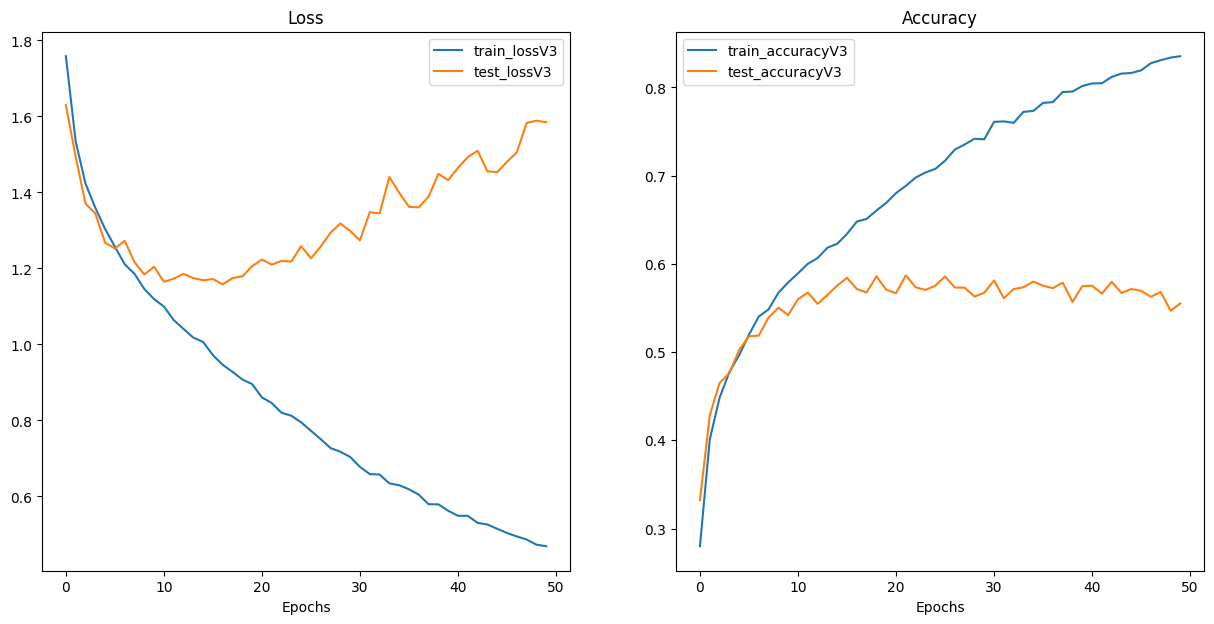

In [51]:
plot_loss_curves(model_results)